In [2]:
# ============================================
# SIMPLE & CLEAN ANOMALY DETECTION NOTEBOOK
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import f1_score
import time

In [3]:
# ============================================
# 1. DATASET
# ============================================

np.random.seed(42)

# Synthetic dataset
X, _ = make_blobs(n_samples=300, centers=2, cluster_std=0.8)
outliers = np.random.uniform(low=-8, high=8, size=(30, 2))
X = np.vstack([X, outliers])
y = np.array([0]*300 + [1]*30)

X = StandardScaler().fit_transform(X)

In [4]:
# ============================================
# 2. MODELS
# ============================================

models = {
    "Isolation Forest": IsolationForest(contamination=0.1),
    "One-Class SVM": OneClassSVM(nu=0.1),
    "LOF": LocalOutlierFactor(contamination=0.1)
}

results = {}

In [5]:
# ============================================
# 3. TRAIN + EVALUATE
# ============================================

for name, model in models.items():
    
    start = time.time()
    
    if name == "LOF":
        pred = model.fit_predict(X)
    else:
        model.fit(X)
        pred = model.predict(X)
    
    pred = (pred == -1).astype(int)
    
    f1 = f1_score(y, pred)
    elapsed = time.time() - start
    
    results[name] = {
        "pred": pred,
        "f1": f1,
        "time": elapsed
    }

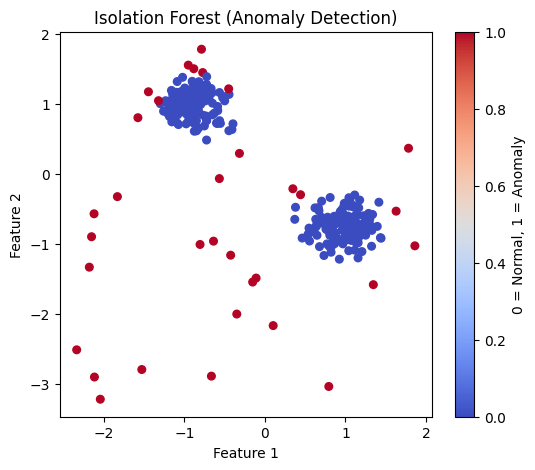

In [6]:
# ============================================
# 4. SIMPLE SCATTER PLOT
# ============================================

plt.figure(figsize=(6,5))

pred = results["Isolation Forest"]["pred"]

plt.scatter(X[:,0], X[:,1],
            c=pred,
            cmap="coolwarm",
            s=30)

plt.title("Isolation Forest (Anomaly Detection)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="0 = Normal, 1 = Anomaly")

plt.show()

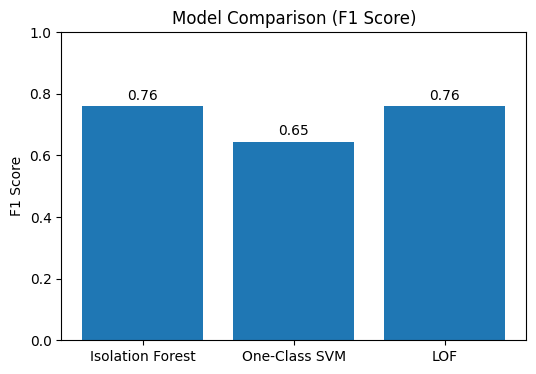

In [7]:
# ============================================
# 5. F1 SCORE COMPARISON
# ============================================

names = list(results.keys())
f1_scores = [results[n]["f1"] for n in names]

plt.figure(figsize=(6,4))

plt.bar(names, f1_scores)

plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")

for i, v in enumerate(f1_scores):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center')

plt.ylim(0,1)

plt.show()

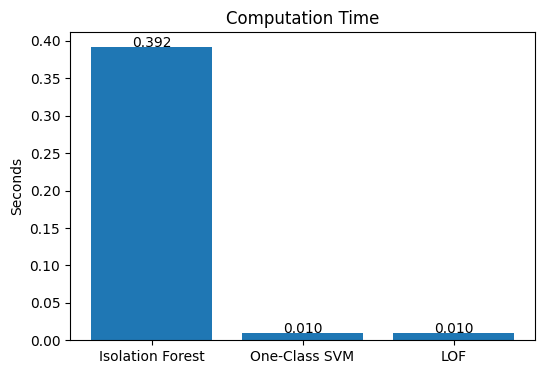

In [8]:
# ============================================
# 6. TIME COMPARISON
# ============================================

times = [results[n]["time"] for n in names]

plt.figure(figsize=(6,4))

plt.bar(names, times)

plt.title("Computation Time")
plt.ylabel("Seconds")

for i, v in enumerate(times):
    plt.text(i, v, f"{v:.3f}", ha='center')

plt.show()

In [9]:

# 7. PRINT RESULTS
  

print("\nModel Performance:\n")

for name in results:
    print(f"{name}: F1 = {results[name]['f1']:.3f}, Time = {results[name]['time']:.4f}s")


Model Performance:

Isolation Forest: F1 = 0.762, Time = 0.3918s
One-Class SVM: F1 = 0.645, Time = 0.0102s
LOF: F1 = 0.762, Time = 0.0100s


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/anomaly_detection.png'

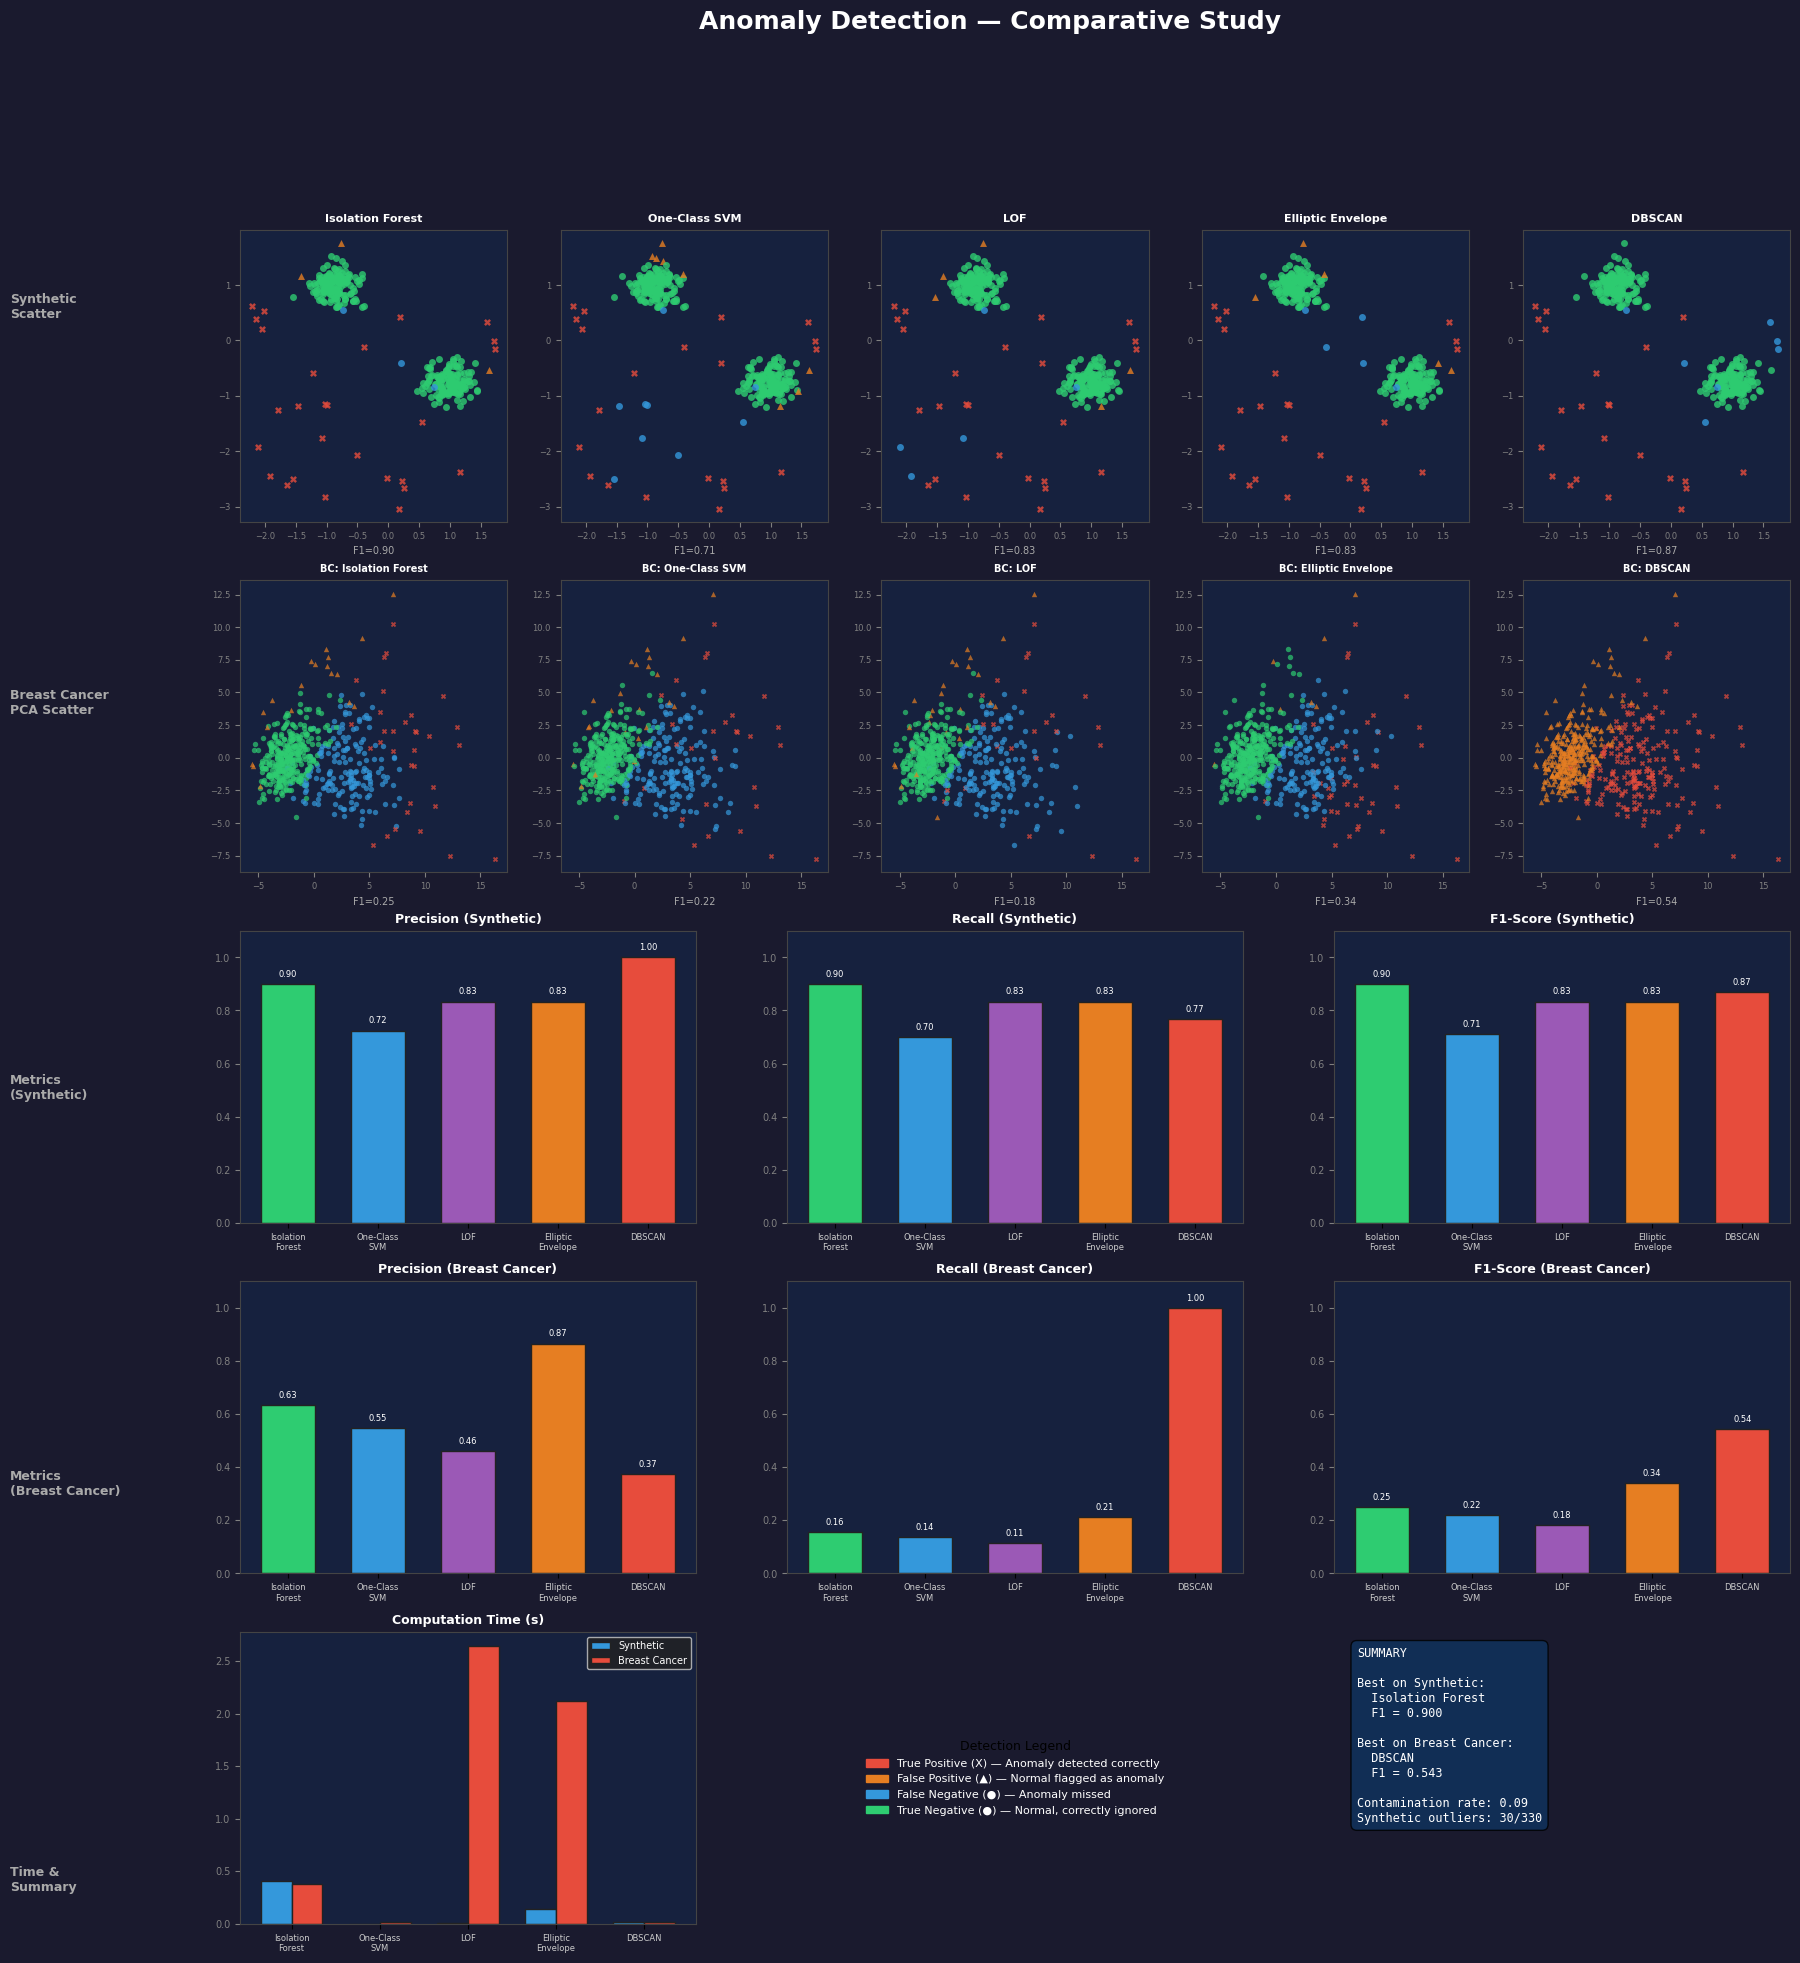

In [10]:
"""
Practical: Anomaly Detection Techniques
Datasets: Breast Cancer + Synthetic (make_blobs with injected outliers)
Methods: Isolation Forest, One-Class SVM, LOF, Elliptic Envelope, DBSCAN
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import DBSCAN
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# ─────────────────────────────────────────────
# 1. DATASET PREPARATION
# ─────────────────────────────────────────────

# --- Dataset A: Synthetic blobs with injected outliers ---
np.random.seed(42)
X_blobs, _ = make_blobs(n_samples=300, centers=2, cluster_std=0.8, random_state=42)
n_outliers = 30
outliers = np.random.uniform(low=-8, high=8, size=(n_outliers, 2))
X_syn = np.vstack([X_blobs, outliers])
y_syn = np.array([0]*300 + [1]*n_outliers)  # 0=normal, 1=anomaly

scaler_syn = StandardScaler()
X_syn_scaled = scaler_syn.fit_transform(X_syn)

# --- Dataset B: Breast Cancer (treat malignant as anomaly) ---
bc = load_breast_cancer()
X_bc = bc.data
y_bc = (bc.target == 0).astype(int)   # malignant=1 (anomaly), benign=0 (normal)

scaler_bc = StandardScaler()
X_bc_scaled = scaler_bc.fit_transform(X_bc)
pca = PCA(n_components=2, random_state=42)
X_bc_2d = pca.fit_transform(X_bc_scaled)

CONTAM = 0.09   # approx malignant ratio in BC dataset

# ─────────────────────────────────────────────
# 2. MODEL DEFINITIONS
# ─────────────────────────────────────────────

models = {
    "Isolation Forest": IsolationForest(contamination=CONTAM, random_state=42),
    "One-Class SVM":    OneClassSVM(nu=CONTAM, kernel="rbf", gamma="auto"),
    "LOF":              LocalOutlierFactor(n_neighbors=20, contamination=CONTAM),
    "Elliptic Envelope":EllipticEnvelope(contamination=CONTAM, random_state=42),
    "DBSCAN":           DBSCAN(eps=0.5, min_samples=5),
}

def get_labels(name, model, X):
    """Return labels: 0=normal, 1=anomaly"""
    t0 = time.time()
    if name == "LOF":
        raw = model.fit_predict(X)
    elif name == "DBSCAN":
        raw = model.fit_predict(X)
        # DBSCAN: -1 = noise = anomaly
        return (raw == -1).astype(int), time.time() - t0
    else:
        model.fit(X)
        raw = model.predict(X)
    elapsed = time.time() - t0
    # sklearn convention: -1=anomaly, 1=normal → convert to 0/1
    return (raw == -1).astype(int), elapsed

# ─────────────────────────────────────────────
# 3. EVALUATE ON BOTH DATASETS
# ─────────────────────────────────────────────

def evaluate(X, y_true, label=""):
    results = {}
    for name, model in models.items():
        pred, elapsed = get_labels(name, model, X)
        p  = precision_score(y_true, pred, zero_division=0)
        r  = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        results[name] = {"Precision": p, "Recall": r, "F1": f1, "Time": elapsed, "pred": pred}
    return results

res_syn = evaluate(X_syn_scaled, y_syn, "Synthetic")
res_bc  = evaluate(X_bc_scaled,  y_bc,  "Breast Cancer")

# ─────────────────────────────────────────────
# 4. VISUALIZATIONS
# ─────────────────────────────────────────────

COLORS = {"TP": "#e74c3c", "FP": "#e67e22", "TN": "#2ecc71", "FN": "#3498db"}
METHOD_COLORS = ["#2ecc71","#3498db","#9b59b6","#e67e22","#e74c3c"]

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor("#1a1a2e")
plt.suptitle("Anomaly Detection — Comparative Study", fontsize=18, fontweight="bold",
             color="white", y=0.98)

# ── Row 1: Synthetic scatter plots (5 methods) ──
for col, (name, res) in enumerate(res_syn.items()):
    ax = fig.add_subplot(5, 5, col+1)
    ax.set_facecolor("#16213e")
    pred = res["pred"]
    for i, (xi, yi, p, gt) in enumerate(zip(X_syn_scaled[:,0], X_syn_scaled[:,1], pred, y_syn)):
        if gt==1 and p==1:   c, m = COLORS["TP"], "X"   # true anomaly detected
        elif gt==0 and p==1: c, m = COLORS["FP"], "^"   # false alarm
        elif gt==1 and p==0: c, m = COLORS["FN"], "o"   # missed anomaly
        else:                c, m = COLORS["TN"], "o"   # normal, correct
        ax.scatter(xi, yi, c=c, marker=m, s=25, alpha=0.8, linewidths=0)
    ax.set_title(name, fontsize=8, color="white", fontweight="bold")
    ax.tick_params(colors="gray", labelsize=6)
    for spine in ax.spines.values(): spine.set_color("#444")
    f1_val = res["F1"]
    ax.set_xlabel(f"F1={f1_val:.2f}", fontsize=7, color="#aaa")

# ── Row 2: Breast Cancer PCA scatter plots (5 methods) ──
for col, (name, res) in enumerate(res_bc.items()):
    ax = fig.add_subplot(5, 5, col+6)
    ax.set_facecolor("#16213e")
    pred = res["pred"]
    for i, (xi, yi, p, gt) in enumerate(zip(X_bc_2d[:,0], X_bc_2d[:,1], pred, y_bc)):
        if gt==1 and p==1:   c, m = COLORS["TP"], "X"
        elif gt==0 and p==1: c, m = COLORS["FP"], "^"
        elif gt==1 and p==0: c, m = COLORS["FN"], "o"
        else:                c, m = COLORS["TN"], "o"
        ax.scatter(xi, yi, c=c, marker=m, s=15, alpha=0.7, linewidths=0)
    ax.set_title(f"BC: {name}", fontsize=7, color="white", fontweight="bold")
    ax.tick_params(colors="gray", labelsize=6)
    for spine in ax.spines.values(): spine.set_color("#444")
    f1_val = res["F1"]
    ax.set_xlabel(f"F1={f1_val:.2f}", fontsize=7, color="#aaa")

# ── Row 3: Bar charts — Precision, Recall, F1 (Synthetic) ──
names = list(res_syn.keys())
x = np.arange(len(names))
width = 0.25

ax_p = fig.add_subplot(5, 3, 7)
ax_r = fig.add_subplot(5, 3, 8)
ax_f = fig.add_subplot(5, 3, 9)

for ax, metric, title in [(ax_p, "Precision", "Precision (Synthetic)"),
                           (ax_r, "Recall",    "Recall (Synthetic)"),
                           (ax_f, "F1",        "F1-Score (Synthetic)")]:
    ax.set_facecolor("#16213e")
    vals = [res_syn[n][metric] for n in names]
    bars = ax.bar(x, vals, color=METHOD_COLORS, edgecolor="#222", width=0.6)
    ax.set_title(title, color="white", fontsize=9, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=6, color="#ccc")
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis="y", colors="gray", labelsize=7)
    for spine in ax.spines.values(): spine.set_color("#444")
    ax.set_facecolor("#16213e")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.2f}",
                ha="center", va="bottom", fontsize=6, color="white")

# ── Row 4: Bar charts — Precision, Recall, F1 (Breast Cancer) ──
ax_p2 = fig.add_subplot(5, 3, 10)
ax_r2 = fig.add_subplot(5, 3, 11)
ax_f2 = fig.add_subplot(5, 3, 12)

for ax, metric, title in [(ax_p2, "Precision", "Precision (Breast Cancer)"),
                           (ax_r2, "Recall",    "Recall (Breast Cancer)"),
                           (ax_f2, "F1",        "F1-Score (Breast Cancer)")]:
    ax.set_facecolor("#16213e")
    vals = [res_bc[n][metric] for n in names]
    bars = ax.bar(x, vals, color=METHOD_COLORS, edgecolor="#222", width=0.6)
    ax.set_title(title, color="white", fontsize=9, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=6, color="#ccc")
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis="y", colors="gray", labelsize=7)
    for spine in ax.spines.values(): spine.set_color("#444")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.2f}",
                ha="center", va="bottom", fontsize=6, color="white")

# ── Row 5: Computation Time + Legend ──
ax_t = fig.add_subplot(5, 3, 13)
ax_t.set_facecolor("#16213e")
times_syn = [res_syn[n]["Time"] for n in names]
times_bc  = [res_bc[n]["Time"]  for n in names]
bw = 0.35
ax_t.bar(x - bw/2, times_syn, width=bw, label="Synthetic", color="#3498db", edgecolor="#222")
ax_t.bar(x + bw/2, times_bc,  width=bw, label="Breast Cancer", color="#e74c3c", edgecolor="#222")
ax_t.set_title("Computation Time (s)", color="white", fontsize=9, fontweight="bold")
ax_t.set_xticks(x)
ax_t.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=6, color="#ccc")
ax_t.tick_params(axis="y", colors="gray", labelsize=7)
for spine in ax_t.spines.values(): spine.set_color("#444")
ax_t.legend(fontsize=7, facecolor="#222", labelcolor="white")

# Legend panel
ax_leg = fig.add_subplot(5, 3, 14)
ax_leg.set_facecolor("#16213e")
ax_leg.axis("off")
legend_items = [
    mpatches.Patch(color=COLORS["TP"], label="True Positive (X) — Anomaly detected correctly"),
    mpatches.Patch(color=COLORS["FP"], label="False Positive (▲) — Normal flagged as anomaly"),
    mpatches.Patch(color=COLORS["FN"], label="False Negative (●) — Anomaly missed"),
    mpatches.Patch(color=COLORS["TN"], label="True Negative (●) — Normal, correctly ignored"),
]
ax_leg.legend(handles=legend_items, loc="center", fontsize=8,
              facecolor="#16213e", labelcolor="white", framealpha=0,
              title="Detection Legend", title_fontsize=9)

# Summary text panel
ax_txt = fig.add_subplot(5, 3, 15)
ax_txt.set_facecolor("#16213e")
ax_txt.axis("off")
best_syn = max(res_syn, key=lambda k: res_syn[k]["F1"])
best_bc  = max(res_bc,  key=lambda k: res_bc[k]["F1"])
summary = (
    f"SUMMARY\n\n"
    f"Best on Synthetic:\n  {best_syn}\n"
    f"  F1 = {res_syn[best_syn]['F1']:.3f}\n\n"
    f"Best on Breast Cancer:\n  {best_bc}\n"
    f"  F1 = {res_bc[best_bc]['F1']:.3f}\n\n"
    f"Contamination rate: {CONTAM}\n"
    f"Synthetic outliers: {n_outliers}/{len(y_syn)}"
)
ax_txt.text(0.05, 0.95, summary, transform=ax_txt.transAxes,
            fontsize=8.5, color="white", va="top", fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#0f3460", alpha=0.8))

# Row labels
fig.text(0.01, 0.845, "Synthetic\nScatter", va="center", ha="left",
         fontsize=9, color="#aaa", rotation=0, fontweight="bold")
fig.text(0.01, 0.665, "Breast Cancer\nPCA Scatter", va="center", ha="left",
         fontsize=9, color="#aaa", rotation=0, fontweight="bold")
fig.text(0.01, 0.49,  "Metrics\n(Synthetic)", va="center", ha="left",
         fontsize=9, color="#aaa", rotation=0, fontweight="bold")
fig.text(0.01, 0.31,  "Metrics\n(Breast Cancer)", va="center", ha="left",
         fontsize=9, color="#aaa", rotation=0, fontweight="bold")
fig.text(0.01, 0.13,  "Time &\nSummary", va="center", ha="left",
         fontsize=9, color="#aaa", rotation=0, fontweight="bold")

plt.tight_layout(rect=[0.05, 0.01, 1.0, 0.97])
plt.savefig("/mnt/user-data/outputs/anomaly_detection.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close()
print("Plot saved.")

# ─────────────────────────────────────────────
# 5. PRINT REPORT
# ─────────────────────────────────────────────

print("\n" + "="*60)
print("ANOMALY DETECTION — METRICS REPORT")
print("="*60)
for ds_name, results in [("Synthetic (blobs + injected outliers)", res_syn),
                          ("Breast Cancer (malignant=anomaly)",    res_bc)]:
    print(f"\n{'─'*60}")
    print(f"Dataset: {ds_name}")
    print(f"{'Method':<22} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Time(s)':>9}")
    print(f"{'─'*60}")
    for name, m in results.items():
        print(f"{name:<22} {m['Precision']:>10.3f} {m['Recall']:>8.3f} {m['F1']:>8.3f} {m['Time']:>9.4f}")
print(f"\n{'='*60}")
print(f"Best on Synthetic:     {best_syn} (F1={res_syn[best_syn]['F1']:.3f})")
print(f"Best on Breast Cancer: {best_bc}  (F1={res_bc[best_bc]['F1']:.3f})")
print("="*60)